## **PSL Data Analysis with Visualization**

The Pakistan Super League (PSL) is a professional T20 cricket league in Pakistan, sanctioned by the Pakistan Cricket Board (PCB). Founded in 2015, the PSL features six franchises representing major cities of Pakistan — Karachi, Lahore, Quetta, Peshawar, Islamabad, and Multan. The league is played in a round-robin group stage followed by playoffs and a grand final. PSL is widely regarded as one of the top T20 leagues in the world and has served as a platform for emerging Pakistani talent alongside international stars. This project explores PSL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

#### **Import All Libraries Used In Data Analysis**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\c_1\Desktop\pandas_practice\Data Visualisation\PSL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,2022-01-27,"Gaddafi Stadium, Lahore",Karachi Kings,Lahore Qalandars,Group,Karachi Kings,bat,181,5,163,5,Karachi Kings,Runs,18,Mohammad Rizwan,Shoaib Malik,89,Sikandar Raza,5--15
1,2,2022-01-28,"Dubai International Cricket Stadium, Dubai",Karachi Kings,Quetta Gladiators,Group,Karachi Kings,field,209,8,177,8,Karachi Kings,Runs,32,Wahab Riaz,Mohammad Haris,87,Zaman Khan,4--53
2,3,2022-01-29,"Arbab Niaz Stadium, Peshawar",Karachi Kings,Peshawar Zalmi,Group,Peshawar Zalmi,bat,157,6,134,4,Karachi Kings,Runs,23,Rovman Powell,Shan Masood,51,Ben Cutting,3--35
3,4,2022-01-30,"Pindi Cricket Stadium, Rawalpindi",Karachi Kings,Islamabad United,Group,Karachi Kings,field,135,8,149,4,Islamabad United,Wickets,4,James Vince,Rovman Powell,65,Liam Dawson,4--13
4,5,2022-01-31,"Dubai International Cricket Stadium, Dubai",Karachi Kings,Multan Sultans,Group,Karachi Kings,bat,175,10,131,7,Karachi Kings,Runs,44,Khushdil Shah,Abdullah Shafique,62,Sikandar Raza,2--12


### **Data Wrangling**

In [3]:
# Create a teams info table
teams_info = pd.DataFrame({
    'match_winner': ['Lahore Qalandars', 'Multan Sultans', 
                     'Peshawar Zalmi', 'Karachi Kings',
                     'Quetta Gladiators', 'Islamabad United'],
    'City': ['Lahore', 'Multan', 'Peshawar', 
             'Karachi', 'Quetta', 'Islamabad'],
    'Home_Ground': ['Gaddafi Stadium', 'Multan Cricket Stadium',
                    'Arbab Niaz Stadium', 'National Stadium',
                    'National Stadium', 'Rawalpindi Cricket Stadium']
})

# Merge with main dataframe
df_merged = pd.merge(df, teams_info, on='match_winner', how='left')
df_merged.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,City,Home_Ground
0,1,2022-01-27,"Gaddafi Stadium, Lahore",Karachi Kings,Lahore Qalandars,Group,Karachi Kings,bat,181,5,...,Karachi Kings,Runs,18,Mohammad Rizwan,Shoaib Malik,89,Sikandar Raza,5--15,Karachi,National Stadium
1,2,2022-01-28,"Dubai International Cricket Stadium, Dubai",Karachi Kings,Quetta Gladiators,Group,Karachi Kings,field,209,8,...,Karachi Kings,Runs,32,Wahab Riaz,Mohammad Haris,87,Zaman Khan,4--53,Karachi,National Stadium
2,3,2022-01-29,"Arbab Niaz Stadium, Peshawar",Karachi Kings,Peshawar Zalmi,Group,Peshawar Zalmi,bat,157,6,...,Karachi Kings,Runs,23,Rovman Powell,Shan Masood,51,Ben Cutting,3--35,Karachi,National Stadium
3,4,2022-01-30,"Pindi Cricket Stadium, Rawalpindi",Karachi Kings,Islamabad United,Group,Karachi Kings,field,135,8,...,Islamabad United,Wickets,4,James Vince,Rovman Powell,65,Liam Dawson,4--13,Islamabad,Rawalpindi Cricket Stadium
4,5,2022-01-31,"Dubai International Cricket Stadium, Dubai",Karachi Kings,Multan Sultans,Group,Karachi Kings,bat,175,10,...,Karachi Kings,Runs,44,Khushdil Shah,Abdullah Shafique,62,Sikandar Raza,2--12,Karachi,National Stadium


Which city's team won the most matches?

In [4]:
city_team = df_merged['City'].value_counts()

Text(0.5, 1.0, 'Matches Won By Cities Team')

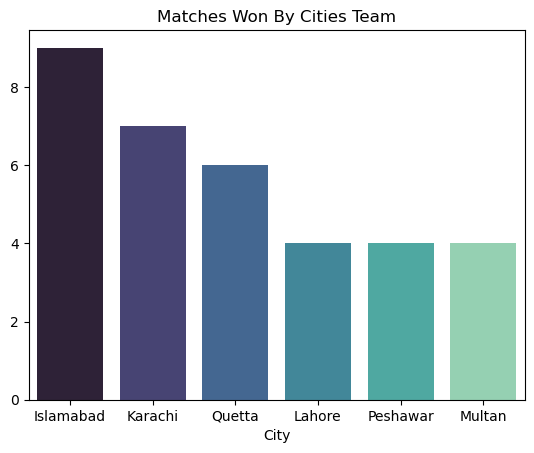

In [5]:
sns.barplot(x = city_team.index, y = city_team.values, palette='mako')
plt.title('Matches Won By Cities Team')

#### **Basic Information**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             34 non-null     int64
 1   date                 34 non-null     str  
 2   venue                34 non-null     str  
 3   team1                34 non-null     str  
 4   team2                34 non-null     str  
 5   stage                34 non-null     str  
 6   toss_winner          34 non-null     str  
 7   toss_decision        34 non-null     str  
 8   first_ings_score     34 non-null     int64
 9   first_ings_wkts      34 non-null     int64
 10  second_ings_score    34 non-null     int64
 11  second_ings_wkts     34 non-null     int64
 12  match_winner         34 non-null     str  
 13  won_by               34 non-null     str  
 14  margin               34 non-null     int64
 15  player_of_the_match  34 non-null     str  
 16  top_scorer           34 non-null     st

#### **Check Rows And Columns**

In [7]:
print(f'Rows are {df.shape[0]} and columns are {df.shape[1]}')

Rows are 34 and columns are 20


#### **Now let's See How Many Columns Have Null values In Total**

In [8]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

#### **Now, Here Comes Some Basic Questions**

1. Which PSL team won the most matches?

In [9]:
df['match_winner'].value_counts()

match_winner
Islamabad United     9
Karachi Kings        7
Quetta Gladiators    6
Lahore Qalandars     4
Peshawar Zalmi       4
Multan Sultans       4
Name: count, dtype: int64

Text(0.5, 0, 'count')

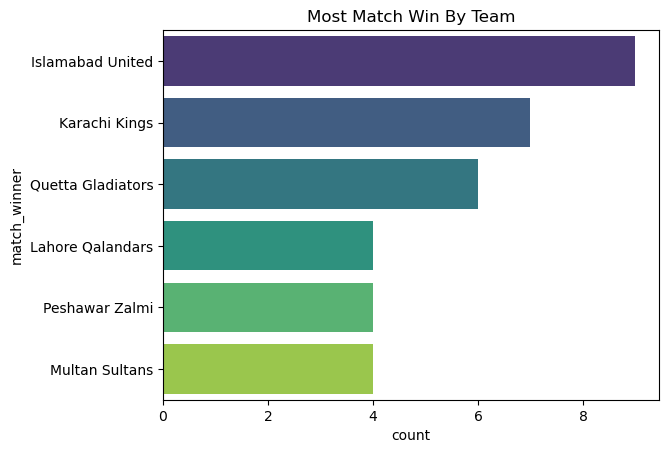

In [10]:
match_win = df['match_winner'].value_counts()
sns.barplot(y = match_win.index, x = match_win.values, palette='viridis')
plt.title('Most Match Win By Team')
plt.xlabel('count')

2. Toss Decision Trends — did teams prefer batting or fielding?

Text(0.5, 1.0, 'Toss Decision Trends')

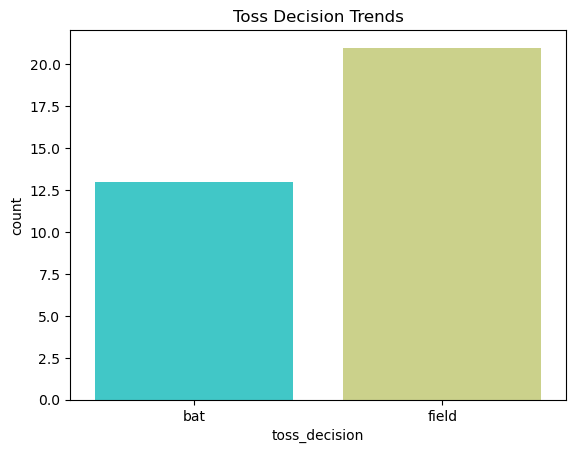

In [11]:
sns.countplot(x = df['toss_decision'], palette='rainbow')
plt.title('Toss Decision Trends')

3. Toss Winner vs Match Winner — does winning the toss help?

In [12]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count / df.shape[0]) * 100
print(f'There is {percentage.round(2)}% chances that the team who won toss will win match')

There is 44.12% chances that the team who won toss will win match


In [13]:
toss_wins = df['toss_winner'].value_counts().reset_index()
toss_wins.columns = ['Team', 'Toss_Wins']

match_wins = df['match_winner'].value_counts().reset_index()
match_wins.columns = ['Team', 'Match_Wins']

# Merge to compare
comparison = pd.merge(toss_wins, match_wins, on='Team', how='outer')
comparison

,Team,Toss_Wins,Match_Wins
0,Islamabad United,7,9
1,Karachi Kings,6,7
2,Lahore Qalandars,5,4
3,Multan Sultans,3,4
4,Peshawar Zalmi,7,4
5,Quetta Gladiators,6,6


4. How do teams win — by Runs or by Wickets?

Text(0.5, 1.0, 'Teams Won by Runs or Wickets')

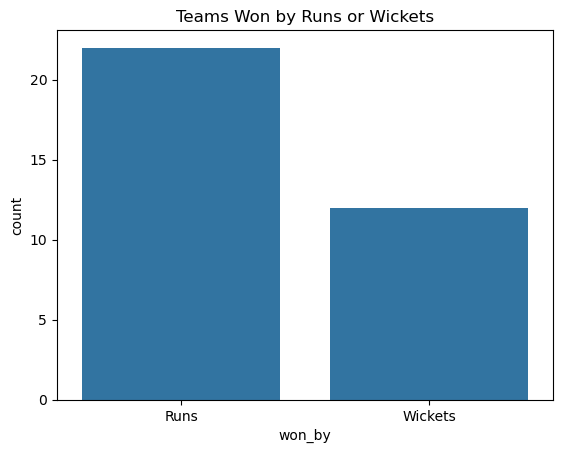

In [14]:
sns.countplot(x = df['won_by'])
plt.title('Teams Won by Runs or Wickets')

#### **Key Player Performances**

1. Most "Player of the Match" awards

In [15]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,2022-01-27,"Gaddafi Stadium, Lahore",Karachi Kings,Lahore Qalandars,Group,Karachi Kings,bat,181,5,163,5,Karachi Kings,Runs,18,Mohammad Rizwan,Shoaib Malik,89,Sikandar Raza,5--15
1,2,2022-01-28,"Dubai International Cricket Stadium, Dubai",Karachi Kings,Quetta Gladiators,Group,Karachi Kings,field,209,8,177,8,Karachi Kings,Runs,32,Wahab Riaz,Mohammad Haris,87,Zaman Khan,4--53
2,3,2022-01-29,"Arbab Niaz Stadium, Peshawar",Karachi Kings,Peshawar Zalmi,Group,Peshawar Zalmi,bat,157,6,134,4,Karachi Kings,Runs,23,Rovman Powell,Shan Masood,51,Ben Cutting,3--35
3,4,2022-01-30,"Pindi Cricket Stadium, Rawalpindi",Karachi Kings,Islamabad United,Group,Karachi Kings,field,135,8,149,4,Islamabad United,Wickets,4,James Vince,Rovman Powell,65,Liam Dawson,4--13
4,5,2022-01-31,"Dubai International Cricket Stadium, Dubai",Karachi Kings,Multan Sultans,Group,Karachi Kings,bat,175,10,131,7,Karachi Kings,Runs,44,Khushdil Shah,Abdullah Shafique,62,Sikandar Raza,2--12


Text(0.5, 1.0, 'Top 10 Player of Match')

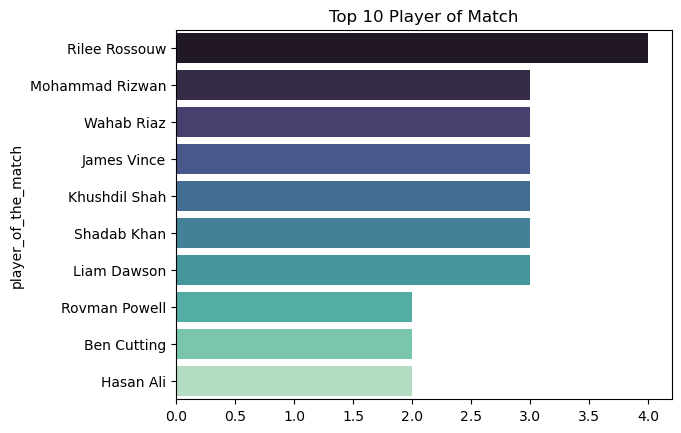

In [16]:
count = df['player_of_the_match'].value_counts().head(10)
sns.barplot(y = count.index, x = count.values, palette='mako')
plt.title('Top 10 Player of Match')

2. Top Scorers — who scored the most runs?

<Axes: title={'center': 'Top 2 Batsman'}, ylabel='top_scorer'>

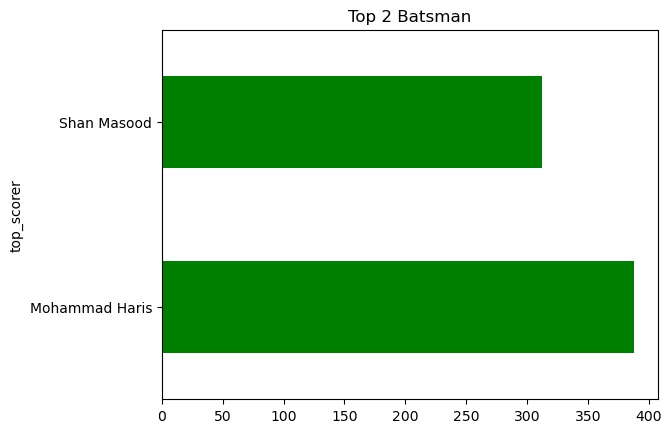

In [17]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high.plot(kind='barh', title='Top 2 Batsman', color='green')

3. Top 10 Best Bowling Figures

In [18]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,2022-01-27,"Gaddafi Stadium, Lahore",Karachi Kings,Lahore Qalandars,Group,Karachi Kings,bat,181,5,163,5,Karachi Kings,Runs,18,Mohammad Rizwan,Shoaib Malik,89,Sikandar Raza,5--15
1,2,2022-01-28,"Dubai International Cricket Stadium, Dubai",Karachi Kings,Quetta Gladiators,Group,Karachi Kings,field,209,8,177,8,Karachi Kings,Runs,32,Wahab Riaz,Mohammad Haris,87,Zaman Khan,4--53
2,3,2022-01-29,"Arbab Niaz Stadium, Peshawar",Karachi Kings,Peshawar Zalmi,Group,Peshawar Zalmi,bat,157,6,134,4,Karachi Kings,Runs,23,Rovman Powell,Shan Masood,51,Ben Cutting,3--35
3,4,2022-01-30,"Pindi Cricket Stadium, Rawalpindi",Karachi Kings,Islamabad United,Group,Karachi Kings,field,135,8,149,4,Islamabad United,Wickets,4,James Vince,Rovman Powell,65,Liam Dawson,4--13
4,5,2022-01-31,"Dubai International Cricket Stadium, Dubai",Karachi Kings,Multan Sultans,Group,Karachi Kings,bat,175,10,131,7,Karachi Kings,Runs,44,Khushdil Shah,Abdullah Shafique,62,Sikandar Raza,2--12


In [19]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype('int')

In [20]:
df.head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,2022-01-27,"Gaddafi Stadium, Lahore",Karachi Kings,Lahore Qalandars,Group,Karachi Kings,bat,181,5,...,5,Karachi Kings,Runs,18,Mohammad Rizwan,Shoaib Malik,89,Sikandar Raza,5--15,5
1,2,2022-01-28,"Dubai International Cricket Stadium, Dubai",Karachi Kings,Quetta Gladiators,Group,Karachi Kings,field,209,8,...,8,Karachi Kings,Runs,32,Wahab Riaz,Mohammad Haris,87,Zaman Khan,4--53,4
2,3,2022-01-29,"Arbab Niaz Stadium, Peshawar",Karachi Kings,Peshawar Zalmi,Group,Peshawar Zalmi,bat,157,6,...,4,Karachi Kings,Runs,23,Rovman Powell,Shan Masood,51,Ben Cutting,3--35,3


<Axes: title={'center': 'Top 5 Bowlers'}, ylabel='best_bowling'>

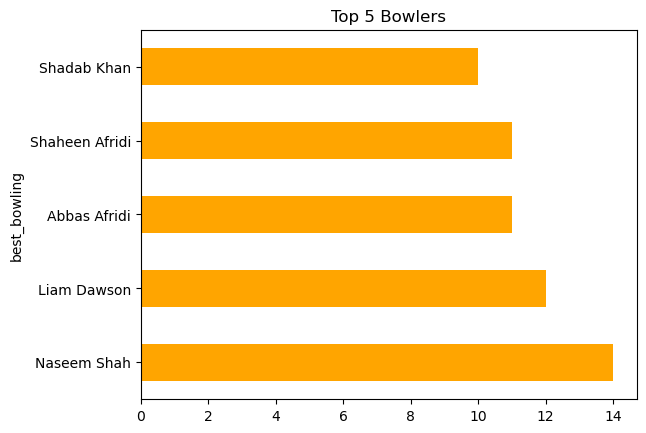

In [21]:
bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head()
bowlers.plot(kind='barh', title='Top 5 Bowlers', color='orange')

#### Venue Analysis:

Which venue hosted the most PSL 2022 matches ?

In [22]:
venue_count = df['venue'].value_counts()
venue_count

venue
Dubai International Cricket Stadium, Dubai    9
Gaddafi Stadium, Lahore                       8
Pindi Cricket Stadium, Rawalpindi             7
Multan Cricket Stadium, Multan                5
Arbab Niaz Stadium, Peshawar                  4
National Stadium, Karachi                     1
Name: count, dtype: int64

Text(0.5, 1.0, 'Matches by Venue')

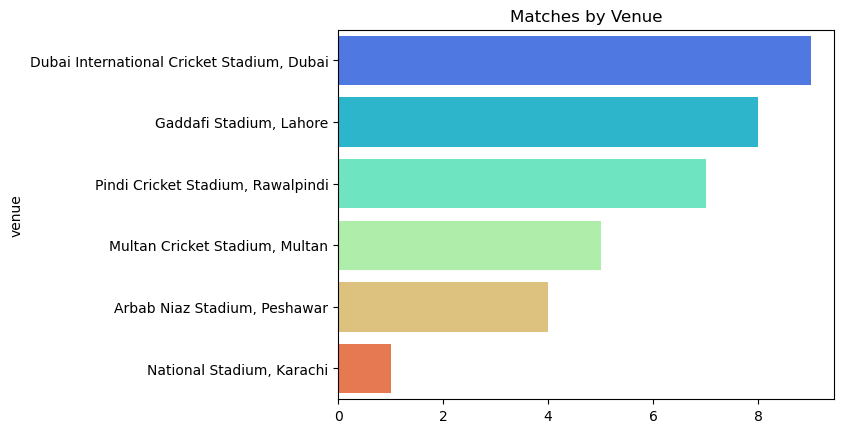

In [23]:
sns.barplot(y = venue_count.index, x = venue_count.values, palette='rainbow')
plt.title('Matches by Venue')

#### Summary

In [24]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore,highest_wickets
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
mean,17.500000,165.147059,7.147059,154.911765,6.852941,19.088235,77.147059,3.088235
std,9.958246,18.802212,2.133888,25.960772,2.017084,16.093228,17.097107,1.356637
min,1.000000,130.000000,4.000000,116.000000,4.000000,1.000000,46.000000,1.000000
25%,9.250000,151.250000,5.000000,134.500000,5.000000,5.250000,63.250000,2.000000
50%,17.500000,163.500000,7.500000,149.500000,7.000000,14.000000,78.000000,3.000000
75%,25.750000,179.500000,9.000000,175.500000,8.000000,31.750000,89.750000,4.000000
max,34.000000,209.000000,10.000000,207.000000,10.000000,49.000000,106.000000,5.000000


#### Custom Questions:

Q1: Which team won by the highest margin of runs?

In [25]:
df.head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,2022-01-27,"Gaddafi Stadium, Lahore",Karachi Kings,Lahore Qalandars,Group,Karachi Kings,bat,181,5,...,5,Karachi Kings,Runs,18,Mohammad Rizwan,Shoaib Malik,89,Sikandar Raza,5--15,5
1,2,2022-01-28,"Dubai International Cricket Stadium, Dubai",Karachi Kings,Quetta Gladiators,Group,Karachi Kings,field,209,8,...,8,Karachi Kings,Runs,32,Wahab Riaz,Mohammad Haris,87,Zaman Khan,4--53,4
2,3,2022-01-29,"Arbab Niaz Stadium, Peshawar",Karachi Kings,Peshawar Zalmi,Group,Peshawar Zalmi,bat,157,6,...,4,Karachi Kings,Runs,23,Rovman Powell,Shan Masood,51,Ben Cutting,3--35,3


In [26]:
df[df['won_by'] == 'Runs'].sort_values(by='margin', ascending=False).head(1)[['match_winner', 'margin']]

,match_winner,margin
9,Quetta Gladiators,49


Q2: Which player had the highest individual score?

In [27]:
df[df['highscore'] == df['highscore'].max()][['top_scorer', 'highscore']]

,top_scorer,highscore
16,Babar Azam,106


Q3: Which bowler had the best bowling figures?

In [28]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
0,Sikandar Raza,5--15
8,Abbas Afridi,5--30
9,Shaheen Afridi,5--13
19,Chris Jordan,5--55
24,Naseem Shah,5--15
27,Mohammad Amir,5--15


Q4: Which venue hosted the most matches?

In [29]:
df['venue'].value_counts()

venue
Dubai International Cricket Stadium, Dubai    9
Gaddafi Stadium, Lahore                       8
Pindi Cricket Stadium, Rawalpindi             7
Multan Cricket Stadium, Multan                5
Arbab Niaz Stadium, Peshawar                  4
National Stadium, Karachi                     1
Name: count, dtype: int64

Q5: How many matches were won by Runs vs Wickets?

In [30]:
df['won_by'].value_counts()

won_by
Runs       22
Wickets    12
Name: count, dtype: int64

Q6: Which teams played the Final and who won?

In [39]:
final = df[df['stage'] == 'Final']
print('Final Teams:', final['team1'].values[0], 'vs', final['team2'].values[0])
print('Winner:', final['match_winner'].values[0])

Final Teams: Islamabad United vs Multan Sultans
Winner: Islamabad United


Q7: What was the average first innings score across all matches?

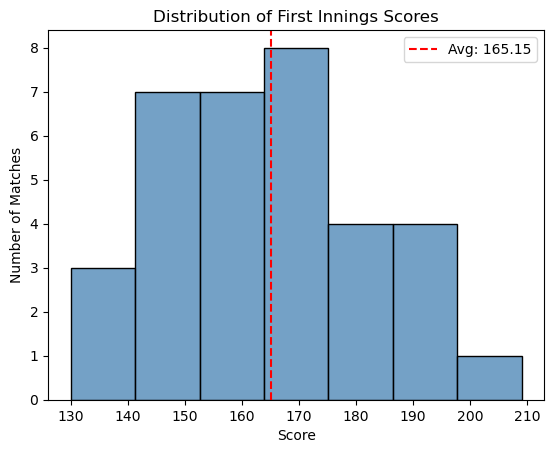

In [38]:
f_inning_score = df['first_ings_score'].mean()

sns.histplot(df['first_ings_score'], bins=7, color='steelblue')
plt.axvline(f_inning_score, color='red', linestyle='--', label=f'Avg: {round(f_inning_score,2)}')
plt.title("Distribution of First Innings Scores")
plt.xlabel("Score")
plt.ylabel("Number of Matches")
plt.legend()


### **Project Complete**